# 02 · Data Cleaning

**Input :** raw 15-minute FIETSERS CSV files for 2023–2025 (`data/raw/cycling/`)  
**Output:** `data/processed/panel_15min_clean.parquet` — one row per (site × 15-min slot), direction-aggregated, extreme counts flagged, gaps flagged"

Sections:
1. Basic data inspection
2. Direction handling (IN + OUT → total flow)
3. Negative / zero / outlier analysis
4. Missing-timestamp analysis
5. Missing-value strategy + forward-fill
6. Save cleaned panel

## 0. Imports & Config

In [40]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
RAW_CYC   = ROOT / "data" / "raw" / "cycling"
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

STUDY_YEARS  = {2023, 2024, 2025}
SPINE_START  = pd.Timestamp("2023-01-01 00:00")
SPINE_END    = pd.Timestamp("2025-12-31 23:45")
# 2023 = 365 days, 2024 = 366 days, 2025 = 365 days → 1096 × 96 = 105,216 slots per station
N_SLOTS      = 1096 * 96

MISS_THRESH  = 0.20   # >20% missing → flagged, not imputed
FFILL_LIMIT  = 4      # max consecutive slots to forward-fill (= 1 hour)
# OUTLIER_STD  = 4      # flag values > expanding(non-zero mean) + N*std per station

CSV_COLS  = ["site ID", "richting", "type", "van", "tot", "aantal"]
USE_COLS  = ["site ID", "richting", "type", "van", "aantal"] # "tot" can be derived from "van" + 15 minutes
COL_TYPES = {"site ID": "Int32", "richting": str, "type": str, "aantal": "float32"}
FNAME_RE  = re.compile(r"data-(\d{4})-(\d{2})\.csv$")

print(f"Spine: {SPINE_START} → {SPINE_END}  ({N_SLOTS:,} slots / station)")

Spine: 2023-01-01 00:00:00 → 2025-12-31 23:45:00  (105,216 slots / station)


## 1. Basic Data Inspection

Load all 2023–2025 FIETSERS rows at full 15-minute granularity, keeping the `richting` column for direction analysis in section 2.

In [41]:
csvs = sorted(
    p for p in RAW_CYC.rglob("*.csv")
    if (m := FNAME_RE.search(p.name)) and int(m.group(1)) in STUDY_YEARS
)

raw = (
    pl.scan_csv(
        csvs,
        has_header=False,
        new_columns=CSV_COLS,
        schema_overrides={
            "site ID": pl.Int32,
            "richting": pl.Utf8,
            "type":     pl.Utf8,
            "van":      pl.Utf8,   # keep as string; pandas parses below
            "aantal":   pl.Float32,
        },
    )
    .filter(pl.col("type") == "FIETSERS")
    .select(["site ID", "richting", "van", "aantal"])
    .collect()
    .to_pandas()
)
raw["van"] = pd.to_datetime(raw["van"], format="mixed")

print(f"Shape       : {raw.shape}")
print(f"\nDtypes:")
print(raw.dtypes)
print(f"\nMissing values per column:")
print(raw.isnull().sum())
print(f"\nUnique site IDs  : {raw['site ID'].nunique()}")
print(f"Unique richting  : {raw['richting'].unique().tolist()}")
print(f"Date range       : {raw['van'].min()} → {raw['van'].max()}")
raw.head(4)

Shape       : (29165328, 4)

Dtypes:
site ID              int32
richting               str
van         datetime64[us]
aantal             float32
dtype: object

Missing values per column:
site ID          0
richting         0
van              0
aantal      402021
dtype: int64

Unique site IDs  : 150
Unique richting  : ['IN', 'OUT']
Date range       : 2023-01-01 00:00:00 → 2025-12-31 23:45:00


,site ID,richting,van,aantal
0,1,IN,2023-01-01 00:00:00,0.0
1,1,IN,2023-01-01 00:15:00,0.0
2,1,IN,2023-01-01 00:30:00,0.0
3,1,IN,2023-01-01 00:45:00,0.0


In [42]:
# ── time-interval distribution ────────────────────────────────────────────────
raw_sorted = raw.sort_values(["site ID", "richting", "van"], ignore_index=True)
raw_sorted["gap_min"] = (
    raw_sorted.groupby(["site ID", "richting"])["van"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

gap_counts = raw_sorted["gap_min"].value_counts().sort_index()
print("Interval distribution (minutes):")

total_gaps = gap_counts.sum()
for gap, cnt in gap_counts.items():
    pct = cnt / total_gaps * 100
    flag = " <- anomaly" if gap != 15.0 else ""
    print(f"  {gap:>8.1f} min : {cnt:>10,} ({pct:.3f}%){flag}")

anomalies = raw_sorted[~raw_sorted["gap_min"].isin([15.0, np.nan])]
print(f"\nAnomalous intervals (not 15 min): {len(anomalies):,} rows")

# ── 75-min gaps: verify DST dates ─────────────────────────────────────────────
dst_gaps = anomalies[anomalies["gap_min"] == 75.0]
print(f"\n75-min gaps ({len(dst_gaps)} rows) — unique dates:")
print(sorted(dst_gaps["van"].dt.date.unique()))

# ── other anomalies: not 15 and not 75 ────────────────────────────────────────
other = anomalies[anomalies["gap_min"] != 75.0].copy()
print(f"\nOther anomalies (not 15 or 75 min): {len(other)} rows")

if len(other):
    # gap_min = X implies (X/15 - 1) slots are missing between two consecutive records
    other["gap_start"]     = other["van"] - pd.to_timedelta(other["gap_min"], unit="min")
    other["missing_slots"] = (other["gap_min"] / 15).astype(int) - 1
    other["missing_days"]  = ((other["gap_min"] - 15) / 60 / 24).round(1)

    display(
        other[["site ID", "richting", "gap_start", "van", "gap_min",
               "missing_slots", "missing_days"]]
        .rename(columns={"gap_start": "gap_from", "van": "gap_to"})
        .sort_values("missing_days", ascending=False)
        .reset_index(drop=True)
    )

Interval distribution (minutes):
      15.0 min : 29,164,744 (99.999%)
      75.0 min :        274 (0.001%) <- anomaly
   44475.0 min :          2 (0.000%) <- anomaly
   77610.0 min :          2 (0.000%) <- anomaly
   93060.0 min :          2 (0.000%) <- anomaly
  299235.0 min :          2 (0.000%) <- anomaly
  575880.0 min :          2 (0.000%) <- anomaly

Anomalous intervals (not 15 min): 284 rows

75-min gaps (274 rows) — unique dates:
[datetime.date(2023, 3, 26)]

Other anomalies (not 15 or 75 min): 10 rows


,site ID,richting,gap_from,gap_to,gap_min,missing_slots,missing_days
0,12,IN,2023-06-28 02:00:00,2024-08-01,575880.0,38391,399.9
1,12,OUT,2023-06-28 02:00:00,2024-08-01,575880.0,38391,399.9
2,80,IN,2024-05-07 04:45:00,2024-12-01,299235.0,19948,207.8
3,80,OUT,2024-05-07 04:45:00,2024-12-01,299235.0,19948,207.8
4,124,IN,2024-08-28 09:00:00,2024-11-01,93060.0,6203,64.6
5,124,OUT,2024-08-28 09:00:00,2024-11-01,93060.0,6203,64.6
6,95,IN,2025-04-08 02:30:00,2025-06-01,77610.0,5173,53.9
7,95,OUT,2025-04-08 02:30:00,2025-06-01,77610.0,5173,53.9
8,119,IN,2024-10-01 02:45:00,2024-11-01,44475.0,2964,30.9
9,119,OUT,2024-10-01 02:45:00,2024-11-01,44475.0,2964,30.9


Conclusion: All large gaps are caused by missing records in the raw CSV

## 2. Direction Handling

AWV files contain separate IN and OUT rows per station per interval.  
We need one row per `(site ID, timestamp)` = total bidirectional flow.

In [43]:
# ── which stations have which directions? ─────────────────────────────────────
dir_summary = (
    raw.groupby("site ID")["richting"]
    .apply(lambda x: frozenset(x.unique()))
    .reset_index(name="directions")
)
dir_counts = dir_summary["directions"].value_counts()
print("Direction combinations across stations:")
for combo, cnt in dir_counts.items():
    print(f"  {set(combo)} : {cnt} stations")

in_out_combined = dir_summary[dir_summary["directions"] == frozenset({"IN/OUT"})]
both_sep        = dir_summary[dir_summary["directions"] == frozenset({"IN","OUT"})]
in_only         = dir_summary[dir_summary["directions"] == frozenset({"IN"})]
out_only        = dir_summary[dir_summary["directions"] == frozenset({"OUT"})]

print(f"\n  IN only          : {len(in_only)} stations")
print(f"  OUT only         : {len(out_only)} stations")
print(f"  Both IN & OUT    : {len(both_sep)} stations")
print(f"  IN/OUT combined  : {len(in_out_combined)} stations")

Direction combinations across stations:
  {'OUT', 'IN'} : 150 stations

  IN only          : 0 stations
  OUT only         : 0 stations
  Both IN & OUT    : 150 stations
  IN/OUT combined  : 0 stations


In [44]:
rows_before = len(raw)

# Polars group_by is ~3-5x faster than pandas on 29M rows.
# Custom aggregation: return null only when ALL inputs are null,
# otherwise sum non-null values (equivalent to pandas min_count=1).
df = (
    pl.from_pandas(raw[["site ID", "van", "aantal"]])
    .group_by(["site ID", "van"])
    .agg(
        pl.when(pl.col("aantal").is_not_null().any())
          .then(pl.col("aantal").sum())
          .otherwise(None)
          .alias("aantal")
    )
    .sort(["site ID", "van"])
    .to_pandas()
)

rows_after = len(df)
print(f"Rows before direction aggregation : {rows_before:,}")
print(f"Rows after  direction aggregation : {rows_after:,}")
print(f"Reduction factor                  : {rows_before/rows_after:.2f}×")
print(f"Unique sites                      : {df['site ID'].nunique()}")
df.head(4)

Rows before direction aggregation : 29,165,328
Rows after  direction aggregation : 14,582,664
Reduction factor                  : 2.00×
Unique sites                      : 150


,site ID,van,aantal
0,1,2023-01-01 00:00:00,0.0
1,1,2023-01-01 00:15:00,0.0
2,1,2023-01-01 00:30:00,0.0
3,1,2023-01-01 00:45:00,0.0


In [45]:
# ── Issue 1 check: verify min_count=1 correctly handles partial NaN ──────
# Aggregation line in the cell above:
#   raw.groupby(["site ID", "van"])["aantal"].sum(min_count=1)
#
# min_count=1: result is NaN only when ALL inputs are NaN
#   IN=5, OUT=NaN  →  5    (correct: partial NaN preserved)
#   IN=NaN, OUT=NaN →  NaN (correct: both NaN stays NaN)

# Fast vectorised check -- pivot NaN mask then compare counts
nan_mask = raw[["site ID", "van", "aantal"]].copy()
nan_mask["is_nan"] = nan_mask["aantal"].isna()

slot_agg = (
    nan_mask.groupby(["site ID", "van"])["is_nan"]
    .agg(n_nan="sum", n_rows="count")
    .reset_index()
)
mixed = slot_agg[(slot_agg["n_nan"] > 0) & (slot_agg["n_nan"] < slot_agg["n_rows"])]

print(f"NaN rows in raw before aggregation           : {raw['aantal'].isna().sum():,}")
print(f"NaN rows in df  after  aggregation           : {df['aantal'].isna().sum():,}")
print(f"Slots with mixed NaN/non-NaN (should survive): {len(mixed):,}")

# spot-check: all mixed slots should be non-NaN in df
sample = mixed.head(5000)
merged = sample[["site ID", "van"]].merge(df, on=["site ID", "van"])
still_nan = merged["aantal"].isna().sum()
print(f"Of first 5000 mixed slots, incorrectly NaN in df: {still_nan}  (should be 0)")

if still_nan == 0:
    print()
    print("Issue 1: min_count=1 already present and working correctly — no fix needed.")
else:
    print()
    print("Issue 1: FIX REQUIRED — partial-NaN slots incorrectly became NaN.")


NaN rows in raw before aggregation           : 402,021
NaN rows in df  after  aggregation           : 200,857
Slots with mixed NaN/non-NaN (should survive): 307
Of first 5000 mixed slots, incorrectly NaN in df: 0  (should be 0)

Issue 1: min_count=1 already present and working correctly — no fix needed.


## 3. Negative and Zero Value Analysis

In [46]:
# ── negatives ─────────────────────────────────────────────────────────────────
n_neg = (df["aantal"] < 0).sum()
print(f"Rows with aantal < 0 : {n_neg:,}")
if n_neg:
    display(df[df["aantal"] < 0].head(5))
df.loc[df["aantal"] < 0, "aantal"] = np.nan
print(f"  → set to NaN")

# ── zeros ─────────────────────────────────────────────────────────────────────
n_zero = (df["aantal"] == 0).sum()
n_total = df["aantal"].notna().sum()
print(f"\nRows with aantal == 0 : {n_zero:,}  ({n_zero/n_total*100:.1f}% of non-NaN)")
print("  → zeros kept as-is (legitimate low-traffic periods)")

Rows with aantal < 0 : 0
  → set to NaN

Rows with aantal == 0 : 4,927,301  (34.3% of non-NaN)
  → zeros kept as-is (legitimate low-traffic periods)


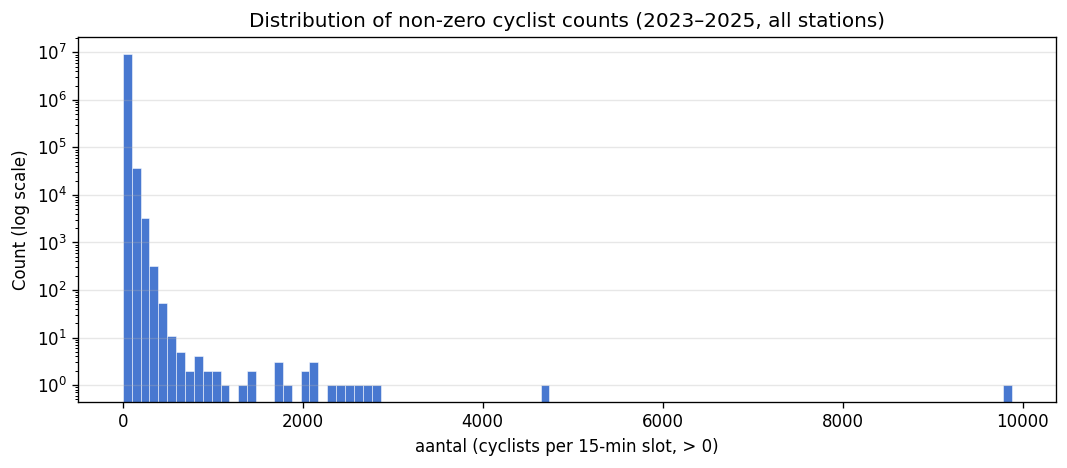

Non-zero count statistics:
count    9454506.0
mean           8.3
std           15.1
min            1.0
50%            4.0
75%            9.0
95%           30.0
99%           71.0
max         9876.0
Name: aantal, dtype: float64


In [47]:
nonzero = df.loc[df["aantal"] > 0, "aantal"].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(nonzero, bins=100, color="#4878d0", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("aantal (cyclists per 15-min slot, > 0)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of non-zero cyclist counts (2023–2025, all stations)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "02_count_distribution.png", dpi=150)
plt.show()

print("Non-zero count statistics:")
print(nonzero.describe(percentiles=[.50, .75, .95, .99]).round(1))

In [48]:
thresholds = (
    df.groupby("site ID")["aantal"]
    .apply(lambda x: x[x > 0].quantile(0.999))
    .rename("threshold")
    .reset_index()
)
df = df.merge(thresholds, on="site ID", how="left")

print("Per-station 99.9th percentile threshold (non-zero values) distribution across stations:")
print(thresholds["threshold"].describe(
    percentiles=[.1, .25, .5, .75, .9]
).round(1))

Per-station 99.9th percentile threshold (non-zero values) distribution across stations:
count    149.0
mean      70.5
std       64.3
min       11.0
10%       21.0
25%       27.6
50%       49.3
75%       86.0
90%      141.6
max      400.4
Name: threshold, dtype: float64


In [49]:
# ── per-station outlier detection (flag only, values preserved) ────────────────
# Threshold = per-station 99.9th percentile of non-zero values (computed above).
# Values above the threshold are flagged as is_outlier; original counts kept.

outlier_mask = df["aantal"] > df["threshold"]
df["is_outlier"] = outlier_mask.astype(bool)
df.drop(columns="threshold", inplace=True)

n_outliers = df["is_outlier"].sum()
outlier_summary = (
    df[df["is_outlier"]]
    .groupby("site ID")["aantal"]
    .agg(n_flagged="count", max_value="max")
    .reset_index()
    .sort_values("n_flagged", ascending=False)
)

print(f"Total outlier rows flagged (> per-station 99.9th pct): {n_outliers:,}")
if len(outlier_summary):
    print(f"Stations with at least one outlier: {len(outlier_summary)}")
    display(outlier_summary.head(10))

print(f"\nOutliers flagged (values kept). Total NaN in aantal: {df['aantal'].isna().sum():,}")

Total outlier rows flagged (> per-station 99.9th pct): 8,972
Stations with at least one outlier: 149


,site ID,n_flagged,max_value
99,100,96,459.0
106,107,96,484.0
68,69,93,429.0
124,125,93,374.0
108,109,91,305.0
136,138,89,413.0
117,118,88,84.0
16,17,88,135.0
15,16,87,217.0
76,77,87,128.0



Outliers flagged (values kept). Total NaN in aantal: 200,857


## 4. Missing Timestamp Analysis

Build a complete 15-minute spine (105,216 slots per station) and left-join the cleaned data to expose all implicit gaps.

In [50]:
all_slots    = pd.date_range(SPINE_START, SPINE_END, freq="15min")
all_stations = df["site ID"].unique()
n_stations   = len(all_stations)

print(f"Spine: {n_stations} stations × {len(all_slots):,} slots = {n_stations*len(all_slots):,} rows")
assert len(all_slots) == N_SLOTS, f"Expected {N_SLOTS} slots, got {len(all_slots)}"

# Polars cross join avoids Python-level 15M-tuple list comprehension;
# Polars join is also faster than pandas merge on 15M rows.
df_pl       = pl.from_pandas(df)
stations_pl = pl.DataFrame({"site ID": pl.Series(all_stations, dtype=pl.Int32)})
slots_pl    = pl.DataFrame({"van": pl.Series(all_slots)})  # datetime64[ns] → Datetime("ns")

df_full = (
    stations_pl
    .join(slots_pl, how="cross")
    .join(df_pl, on=["site ID", "van"], how="left")
    .with_columns(pl.col("is_outlier").fill_null(False))
    .to_pandas()
)

print(f"Full panel rows : {len(df_full):,}")
print(f"Implicit + explicit NaN in aantal: {df_full['aantal'].isna().sum():,}")

Spine: 150 stations × 105,216 slots = 15,782,400 rows
Full panel rows : 15,782,400
Implicit + explicit NaN in aantal: 1,400,593


Missing-data distribution across stations:
    0%       :    0 stations
  (  0–  5%] :  124 stations
  (  5– 20%] :    9 stations
  ( 20– 50%] :    5 stations
  ( 50–100%] :   12 stations

Stations > 20% missing → will be flagged: 17

Stations with longest consecutive gap > 7 days: 43


,site ID,pct_missing,max_consec_days
0,144,100.000000,1096.0
1,152,94.286991,1033.4
2,151,93.105611,1020.4
3,150,93.025776,1019.6
4,149,88.458980,969.5
5,148,88.005627,964.5
6,147,87.915336,963.6
7,146,79.602912,872.4
8,145,79.522126,871.6
9,142,96.259124,784.0


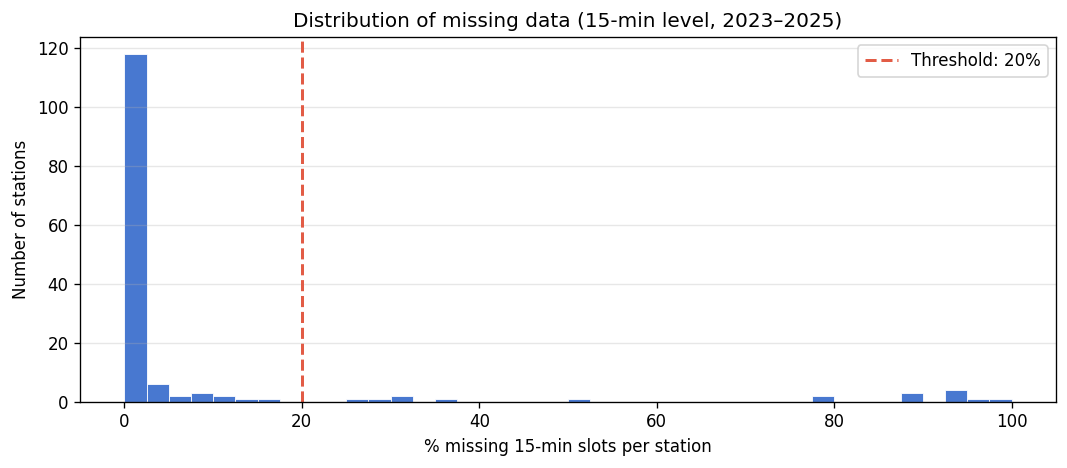


Stations with >20% missing:


,site ID,n_expected,n_actual,n_missing,pct_missing,max_consec_slots,max_consec_days
0,144,105216,0,105216,100.000000,105216,1096.0
1,142,105216,3936,101280,96.259124,75264,784.0
2,152,105216,6011,99205,94.286991,99205,1033.4
3,151,105216,7254,97962,93.105611,97962,1020.4
4,150,105216,7338,97878,93.025776,97878,1019.6
5,123,105216,7526,97690,92.847095,75108,782.4
6,149,105216,12143,93073,88.458980,93073,969.5
7,148,105216,12620,92596,88.005627,92596,964.5
8,147,105216,12715,92501,87.915336,92501,963.6
9,146,105216,21461,83755,79.602912,83755,872.4


In [51]:
# ── per-station missing statistics ────────────────────────────────────────────
miss_stats = (
    df_full.groupby("site ID")["aantal"]
    .agg(
        n_expected = lambda s: N_SLOTS,
        n_actual   = lambda s: s.notna().sum(),
        n_missing  = lambda s: s.isna().sum(),
    )
    .assign(pct_missing=lambda x: x["n_missing"] / x["n_expected"] * 100)
    .reset_index()
)

# ── longest consecutive missing block per station ──────────────────────────────
def max_consec_missing(s):
    is_nan = s.isna()
    if not is_nan.any():
        return 0
    blocks = (is_nan != is_nan.shift()).cumsum()
    return int(is_nan.groupby(blocks).sum().max())

miss_stats["max_consec_slots"] = (
    df_full.groupby("site ID")["aantal"]
    .apply(max_consec_missing)
    .values
)
miss_stats["max_consec_days"] = (miss_stats["max_consec_slots"] * 15 / 60 / 24).round(1)

bins = [0, 5, 20, 50, 100]
print("Missing-data distribution across stations:")
exact_zero = (miss_stats["pct_missing"] == 0).sum()
print(f"    0%       : {exact_zero:>4} stations")
for lo, hi in zip(bins, bins[1:]):
    mask = (miss_stats["pct_missing"] > lo) & (miss_stats["pct_missing"] <= hi)
    print(f"  ({lo:>3}–{hi:>3}%] : {mask.sum():>4} stations")

n_high = (miss_stats["pct_missing"] > MISS_THRESH * 100).sum()
print(f"\nStations > {MISS_THRESH*100:.0f}% missing → will be flagged: {n_high}")

# ── long consecutive gap summary ───────────────────────────────────────────────
LONG_GAP_DAYS = 7
long_gap = miss_stats[miss_stats["max_consec_days"] > LONG_GAP_DAYS].sort_values(
    "max_consec_days", ascending=False
)
print(f"\nStations with longest consecutive gap > {LONG_GAP_DAYS} days: {len(long_gap)}")
if len(long_gap):
    display(long_gap[["site ID", "pct_missing", "max_consec_days"]].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(miss_stats["pct_missing"], bins=40, color="#4878d0",
        edgecolor="white", linewidth=0.5)
ax.axvline(MISS_THRESH * 100, color="#e25c46", lw=1.8, ls="--",
           label=f"Threshold: {MISS_THRESH*100:.0f}%")
ax.set_xlabel("% missing 15-min slots per station")
ax.set_ylabel("Number of stations")
ax.set_title("Distribution of missing data (15-min level, 2023–2025)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "02_missing_histogram.png", dpi=150)
plt.show()

print("\nStations with >20% missing:")
display(
    miss_stats[miss_stats["pct_missing"] > MISS_THRESH * 100]
    .sort_values("pct_missing", ascending=False)
    .reset_index(drop=True)
)

## 5. Handle Missing Values

**Strategy:**

| Station type | `% missing` | Action |
|---|---|---|
| Low-coverage | > 20% | Flag `low_coverage = True`; leave NaN as-is |
| Well-covered | ≤ 20% | Forward-fill up to **4 consecutive slots (= 1 hour)**; remaining long gaps stay NaN |

In [52]:
# ── flag ──────────────────────────────────────────────────────────────────────
low_cov_ids = set(
    miss_stats.loc[miss_stats["pct_missing"] > MISS_THRESH * 100, "site ID"]
)
df_full["low_coverage"] = df_full["site ID"].isin(low_cov_ids)

print(f"low_coverage = True  : {df_full['low_coverage'].sum():,} rows  "
      f"({len(low_cov_ids)} stations)")
print(f"low_coverage = False : {(~df_full['low_coverage']).sum():,} rows  "
      f"({df_full[~df_full['low_coverage']]['site ID'].nunique()} stations)")

df_clean = df_full.copy()

low_coverage = True  : 1,788,672 rows  (17 stations)
low_coverage = False : 13,993,728 rows  (133 stations)


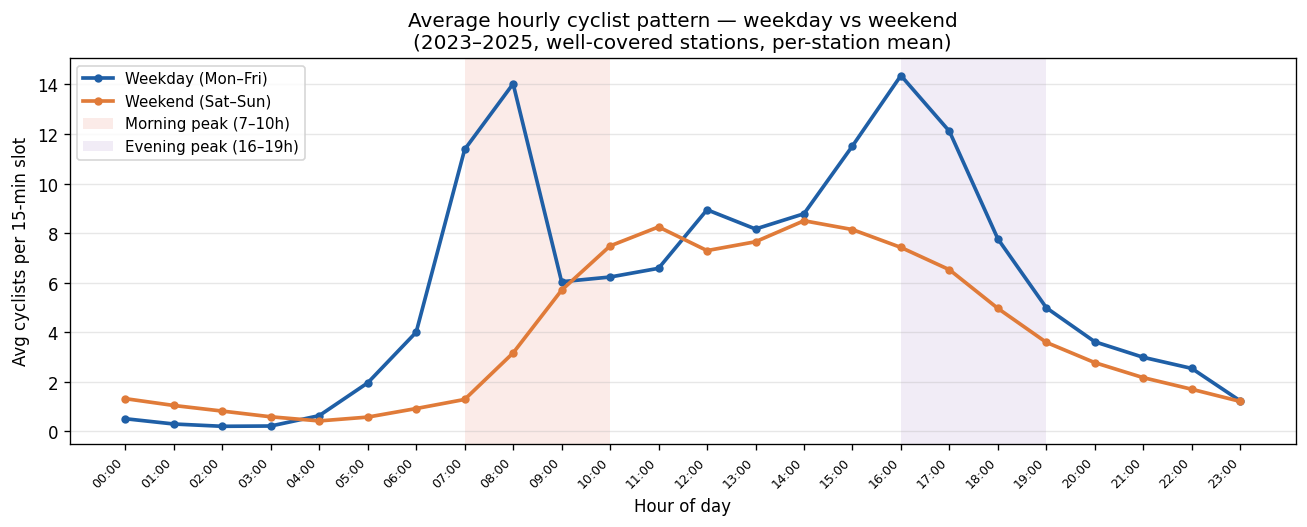

Weekday mean (all hours)         : 5.79
Morning avg (7–9h)  : 10.48  → 1.81x mean
Evening avg (16–18h) : 11.41  → 1.97x mean
Weekend peak hour                : 14:00

✓  Twin peak pattern visible — data looks correct.


In [53]:
# ── sanity check: average hourly cyclist pattern — weekday vs weekend ─────────
tmp = df_clean[["van", "aantal", "low_coverage"]].copy()
tmp["hour"]       = tmp["van"].dt.hour
tmp["dayofweek"]  = tmp["van"].dt.dayofweek
tmp["is_weekend"] = tmp["dayofweek"] >= 5

tmp_good = tmp[~tmp["low_coverage"] & tmp["aantal"].notna()]

hourly_avg = (
    tmp_good.groupby(["is_weekend", "hour"])["aantal"]
    .mean()
    .reset_index(name="avg_aantal")
)
weekday = hourly_avg[~hourly_avg["is_weekend"]].sort_values("hour")
weekend = hourly_avg[ hourly_avg["is_weekend"]].sort_values("hour")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(weekday["hour"], weekday["avg_aantal"],
        color="#1f5fa6", lw=2.2, marker="o", ms=4, label="Weekday (Mon–Fri)")
ax.plot(weekend["hour"], weekend["avg_aantal"],
        color="#e07b39", lw=2.2, marker="o", ms=4, label="Weekend (Sat–Sun)")

ax.axvspan(7,  10, color="#e25c46", alpha=0.12, lw=0, label="Morning peak (7–10h)")
ax.axvspan(16, 19, color="#9467bd", alpha=0.12, lw=0, label="Evening peak (16–19h)")

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)],
                   rotation=45, ha="right", fontsize=7.5)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg cyclists per 15-min slot")
ax.set_title(
    "Average hourly cyclist pattern — weekday vs weekend\n"
    "(2023–2025, well-covered stations, per-station mean)"
)
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "02_hourly_pattern.png", dpi=150)
plt.show()

# ── verify peak visibility ─────────────────────────────────────────────────
wd_mean = weekday["avg_aantal"].mean()
wd_morn = weekday.loc[weekday["hour"].isin([7, 8, 9]), "avg_aantal"].mean()
wd_eve  = weekday.loc[weekday["hour"].isin([16, 17, 18]), "avg_aantal"].mean()
we_peak = int(weekend.loc[weekend["avg_aantal"].idxmax(), "hour"])

morn_ratio = wd_morn / wd_mean
eve_ratio  = wd_eve  / wd_mean

THRESHOLD = 1.3
print(f"Weekday mean (all hours)         : {wd_mean:.2f}")
print(f"Morning avg (7–9h)  : {wd_morn:.2f}  → {morn_ratio:.2f}x mean")
print(f"Evening avg (16–18h) : {wd_eve:.2f}  → {eve_ratio:.2f}x mean")
print(f"Weekend peak hour                : {we_peak:02d}:00")

has_morn = morn_ratio > THRESHOLD
has_eve  = eve_ratio  > THRESHOLD

if has_morn and has_eve:
    print(f"\n✓  Twin peak pattern visible — data looks correct.")
else:
    if not has_morn:
        print(f"\n⚠  WARNING: Morning peak (7–9h) not elevated (ratio={morn_ratio:.2f}, need >{THRESHOLD}).")
    if not has_eve:
        print(f"\n⚠  WARNING: Evening peak (16–18h) not elevated (ratio={eve_ratio:.2f}, need >{THRESHOLD}).")

## 6. Save Cleaned Panel

In [54]:
# merge sites metadata before saving
SITES_COLS = ["site ID", "site nr", "long", "lat", "naam",
              "domein", "wegnr", "district", "gemeente",
              "interval", "datum_van"]
SITE_KEEP = ["site ID", "long", "lat", "naam", "gemeente",
             "wegnr", "district", "datum_van"]

sites = pd.read_csv(
    RAW_CYC / "sites.csv",
    header=None, names=SITES_COLS,
    dtype={"site ID": int, "site nr": "Int64",
           "long": float, "lat": float, "interval": "Int16"},
    parse_dates=["datum_van"],
)[SITE_KEEP]

df_clean = df_clean.merge(sites, on="site ID", how="left")

META_COLS  = [c for c in SITE_KEEP[1:] if c in df_clean.columns]
FINAL_COLS = ["site ID", "van", "aantal", "is_outlier", "low_coverage"] + META_COLS
df_clean   = df_clean[FINAL_COLS]

out_path = PROCESSED / "panel_15min_clean.parquet"
df_clean.to_parquet(out_path, index=False)

size_mb = out_path.stat().st_size / 1_048_576
print("=" * 55)
print("panel_15min_clean.parquet — summary")
print("=" * 55)
print(f"  Shape                : {df_clean.shape}")
print(f"  Unique stations      : {df_clean['site ID'].nunique()}")
print(f"  Date range           : {df_clean['van'].min()} → {df_clean['van'].max()}")
print(f"  Low-coverage stations: {len(low_cov_ids)}")
print(f"  Outlier rows flagged : {df_clean['is_outlier'].sum():,}")
print(f"  Total NaN (aantal)   : {df_clean['aantal'].isna().sum():,}")
print(f"  File size            : {size_mb:.1f} MB")
print(f"  Columns              : {df_clean.columns.tolist()}")
display(df_clean.head(4))

panel_15min_clean.parquet — summary
  Shape                : (15782400, 12)
  Unique stations      : 150
  Date range           : 2023-01-01 00:00:00 → 2025-12-31 23:45:00
  Low-coverage stations: 17
  Outlier rows flagged : 8,972
  Total NaN (aantal)   : 1,400,593
  File size            : 52.0 MB
  Columns              : ['site ID', 'van', 'aantal', 'is_outlier', 'low_coverage', 'long', 'lat', 'naam', 'gemeente', 'wegnr', 'district', 'datum_van']


,site ID,van,aantal,is_outlier,low_coverage,long,lat,naam,gemeente,wegnr,district,datum_van
0,1,2023-01-01 00:00:00,0.0,False,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
1,1,2023-01-01 00:15:00,0.0,False,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
2,1,2023-01-01 00:30:00,0.0,False,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
3,1,2023-01-01 00:45:00,0.0,False,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22


## 7. Validation: Investigate the 17 Low-Coverage Stations

Classify each low-coverage station by likely cause (late installation vs. sensor malfunction / data gap) and measure the longest consecutive missing run.

In [55]:
panel = pd.read_parquet(PROCESSED / "panel_15min_clean.parquet")

# date_if_valid is NaN when aantal is NaN, so min/max give first/last observed day
panel_lc = panel[panel["low_coverage"] == True].copy()
panel_lc["date_if_valid"] = panel_lc["datum_van"].where(panel_lc["aantal"].notna())

low_cov_sites = (
    panel_lc
    .groupby(["site ID", "naam", "gemeente", "datum_van"])
    .agg(
        missing_pct  = ("aantal", lambda x: x.isna().mean() * 100),
        first_valid  = ("date_if_valid", "min"),
        last_valid   = ("date_if_valid", "max"),
        n_valid_days = ("aantal", "count")
    )
    .reset_index()
    .sort_values("missing_pct", ascending=False)
)

print("The 17 low-coverage stations:")
print(low_cov_sites[[
    "naam", "gemeente", "datum_van",
    "missing_pct", "first_valid", "last_valid", "n_valid_days"
]].to_string())

# Classify reason for each station
study_start = pd.Timestamp("2023-01-01")

low_cov_sites["likely_reason"] = low_cov_sites.apply(
    lambda row: "late_installation"
    if pd.to_datetime(row["datum_van"]) > study_start
    else "sensor_malfunction_or_gap",
    axis=1
)

print("\nSummary by likely reason:")
print(low_cov_sites["likely_reason"].value_counts())

# For sensor malfunction cases:
# check if gaps are clustered or random
print("\nEarly-install but high-missing stations:")
early = low_cov_sites[
    low_cov_sites["likely_reason"] == "sensor_malfunction_or_gap"
]
if len(early) > 0:
    for _, row in early.iterrows():
        site_data = panel[panel["site ID"] == row["site ID"]]
        # Find longest consecutive gap
        missing_mask = site_data["aantal"].isna()
        gap_lengths = []
        current_gap = 0
        for val in missing_mask:
            if val:
                current_gap += 1
            else:
                if current_gap > 0:
                    gap_lengths.append(current_gap)
                current_gap = 0
        max_gap = max(gap_lengths) if gap_lengths else 0
        print(f"  {row['naam'][:25]:25s} "
              f"missing={row['missing_pct']:.1f}% "
              f"max_gap={max_gap} days "
              f"install={row['datum_van']}")

The 17 low-coverage stations:
                                 naam                        gemeente  datum_van  missing_pct first_valid last_valid  n_valid_days
8                         test leuven                          Leuven 2024-01-12   100.000000         NaT        NaT             0
6   TEST Validatie BRUGGE Y2H22022134                          Brugge 2023-10-24    96.259125  2023-10-24 2023-10-24          3936
15                             Opwijk  District Vilvoorde-gewestwegen 2025-10-31    94.286987  2025-10-31 2025-10-31          6011
14                             Leuven                 District Leuven 2025-10-18    93.105614  2025-10-18 2025-10-18          7254
13                             Bertem                 District Leuven 2025-10-17    93.025772  2025-10-17 2025-10-17          7338
5                    Beveren teller 1                         Beveren 2022-10-06    92.847099  2022-10-06 2022-10-06          7526
12                          Hoeilaart                